In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('All libraries imported!')

All libraries imported!


In [2]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print(f'Train size: {train.shape}')
print(f'Test size: {test.shape}')
train.head()

Train size: (1460, 81)
Test size: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Outliers removed: 2 rows


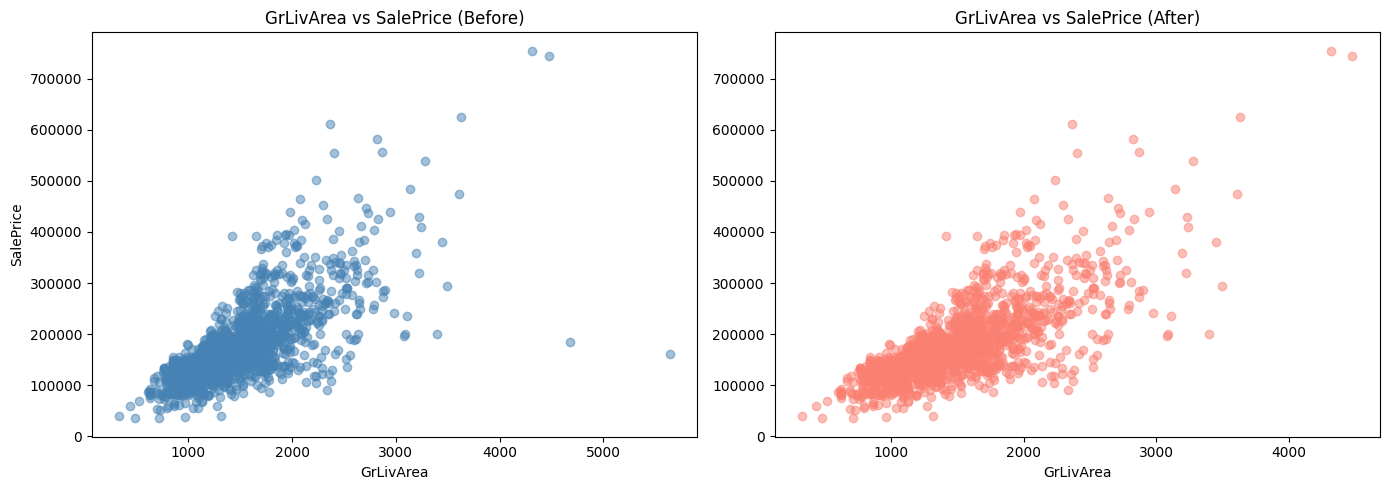

Training set size after removal: (1458, 81)


In [3]:
# Visualize outliers before removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, color='steelblue')
axes[0].set_title('GrLivArea vs SalePrice (Before)')
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')

# Remove outliers: large area but very low price
outlier_idx = train[(train['GrLivArea'] > 4500) & (train['SalePrice'] < 200000)].index
print(f'Outliers removed: {len(outlier_idx)} rows')
train = train.drop(outlier_idx)

axes[1].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, color='salmon')
axes[1].set_title('GrLivArea vs SalePrice (After)')
axes[1].set_xlabel('GrLivArea')

plt.tight_layout()
plt.savefig('outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Training set size after removal: {train.shape}')

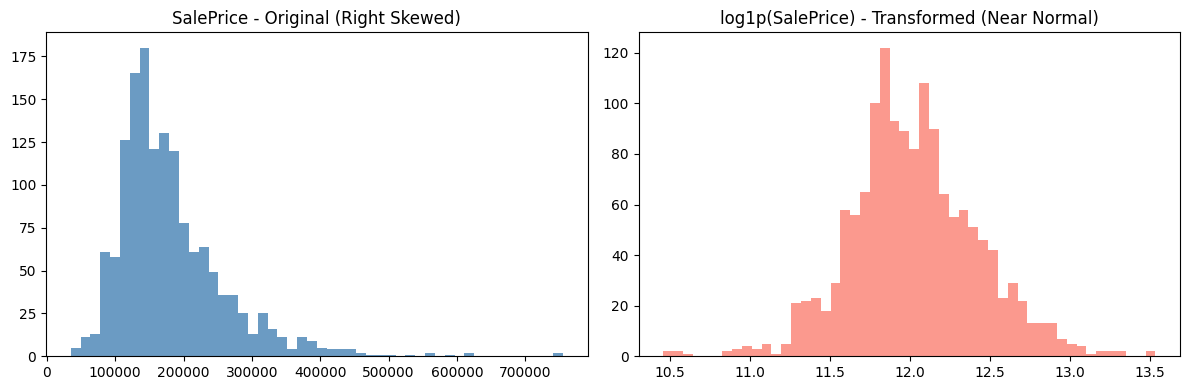

In [4]:
# log1p transformation to normalize SalePrice
y_train = np.log1p(train['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('SalePrice - Original (Right Skewed)')
axes[1].hist(y_train, bins=50, color='salmon', alpha=0.8)
axes[1].set_title('log1p(SalePrice) - Transformed (Near Normal)')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

In [5]:
# Combine train and test for unified processing
combined = pd.concat([train.drop('SalePrice', axis=1), test], axis=0).reset_index(drop=True)
print(f'Combined size: {combined.shape}')

# Categorical features: fill with 'None' (means no such facility)
cat_none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType', 'MSSubClass'
]
for col in cat_none_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna('None')

# Numeric features: fill with 0
num_zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_zero_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna(0)

# Remaining categorical: fill with mode
cat_cols = combined.select_dtypes(include=['object']).columns
for col in cat_cols:
    combined[col] = combined[col].fillna(combined[col].mode()[0])

# Remaining numeric: fill with median
num_cols = combined.select_dtypes(include=[np.number]).columns
for col in num_cols:
    combined[col] = combined[col].fillna(combined[col].median())

print(f'Missing values after cleaning: {combined.isnull().sum().sum()}')
print('Data cleaning complete!')

Combined size: (2917, 80)
Missing values after cleaning: 0
Data cleaning complete!


In [6]:
# --- Basic derived features ---
# Total area (most important feature)
combined['TotalSF'] = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']

# House age features
combined['HouseAge'] = combined['YrSold'] - combined['YearBuilt']
combined['RemodAge'] = combined['YrSold'] - combined['YearRemodAdd']
combined['IsRemodeled'] = (combined['YearBuilt'] != combined['YearRemodAdd']).astype(int)

# Bathroom count
combined['TotalBath'] = (combined['FullBath'] + 0.5 * combined['HalfBath'] +
                         combined['BsmtFullBath'] + 0.5 * combined['BsmtHalfBath'])

# Binary presence features
combined['HasGarage'] = (combined['GarageArea'] > 0).astype(int)
combined['HasBasement'] = (combined['TotalBsmtSF'] > 0).astype(int)
combined['HasPool'] = (combined['PoolArea'] > 0).astype(int)
combined['HasFireplace'] = (combined['Fireplaces'] > 0).astype(int)

# --- Advanced derived features ---
# Porch total area
combined['TotalPorchSF'] = (combined['OpenPorchSF'] + combined['EnclosedPorch'] +
                             combined['3SsnPorch'] + combined['ScreenPorch'])

# Living area per room
combined['AreaPerRoom'] = combined['GrLivArea'] / (combined['TotRmsAbvGrd'] + 1)

# Is it a new house (built within 5 years of sale)
combined['IsNew'] = (combined['HouseAge'] <= 5).astype(int)

# Overall quality × area interaction
combined['QualArea'] = combined['OverallQual'] * combined['TotalSF']

print('Feature engineering complete!')
print(f'New features added: TotalSF, HouseAge, RemodAge, IsRemodeled, TotalBath,')
print(f'                    HasGarage, HasBasement, HasPool, HasFireplace,')
print(f'                    TotalPorchSF, AreaPerRoom, IsNew, QualArea')

Feature engineering complete!
New features added: TotalSF, HouseAge, RemodAge, IsRemodeled, TotalBath,
                    HasGarage, HasBasement, HasPool, HasFireplace,
                    TotalPorchSF, AreaPerRoom, IsNew, QualArea


In [7]:
# Label encode categorical features
cat_cols = combined.select_dtypes(include=['object']).columns
print(f'Categorical features to encode: {len(cat_cols)}')

le = LabelEncoder()
for col in cat_cols:
    combined[col] = le.fit_transform(combined[col].astype(str))

# Drop ID
combined = combined.drop(['Id'], axis=1, errors='ignore')

# Split back
X_train = combined.iloc[:len(train)]
X_test = combined.iloc[len(train):]

print(f'Training features: {X_train.shape}')
print(f'Test features: {X_test.shape}')

Categorical features to encode: 43
Training features: (1458, 92)
Test features: (1459, 92)


In [8]:
# Use RobustScaler for better outlier resistance
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cross-validation helper
def rmse_cv(model, X, y, n_folds=5):
    kf = KFold(n_folds, shuffle=True, random_state=42)
    rmse = np.sqrt(-cross_val_score(model, X, y,
                                     scoring='neg_mean_squared_error', cv=kf))
    return rmse

# Define models
models = {
    'Lasso': make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=42)),
    'Ridge': make_pipeline(RobustScaler(), Ridge(alpha=10, random_state=42)),
    'ElasticNet': make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=42)),
    'GBDT': GradientBoostingRegressor(
        n_estimators=3000, learning_rate=0.05, max_depth=4,
        max_features='sqrt', min_samples_leaf=15,
        min_samples_split=10, loss='huber', random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=3000, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.005, reg_lambda=1,
        random_state=42, verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=3000, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.005, reg_lambda=1,
        random_state=42, verbose=-1
    )
}

results = {}
print('=== 5-Fold CV RMSE (Lower is Better) ===')
for name, model in models.items():
    scores = rmse_cv(model, X_train_scaled, y_train)
    results[name] = scores
    print(f'{name:12s}: mean={scores.mean():.4f}, std={scores.std():.4f}')

=== 5-Fold CV RMSE (Lower is Better) ===
Lasso       : mean=0.1210, std=0.0096
Ridge       : mean=0.1211, std=0.0095
ElasticNet  : mean=0.1210, std=0.0096
GBDT        : mean=0.1165, std=0.0088
XGBoost     : mean=0.1184, std=0.0056
LightGBM    : mean=0.1247, std=0.0074


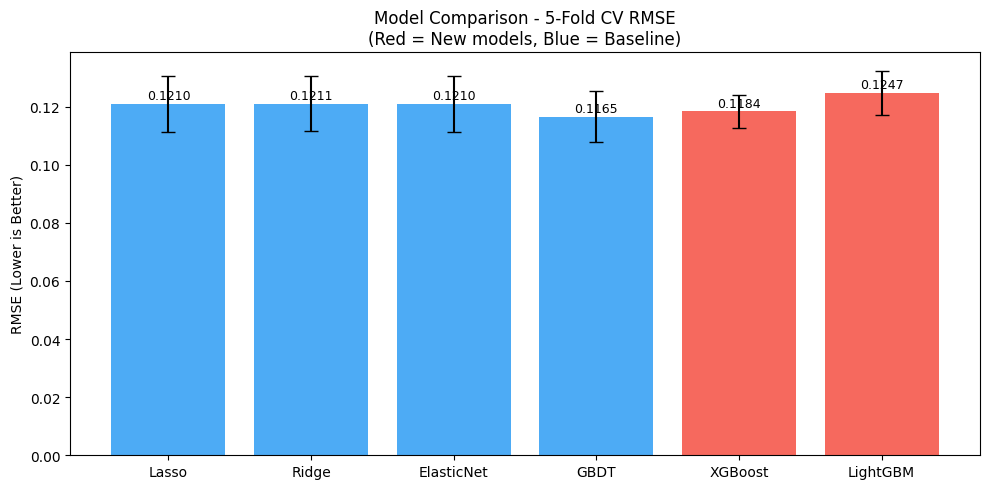

Best single model: GBDT (RMSE=0.1165)


In [9]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 5))
model_names = list(results.keys())
means = [results[m].mean() for m in model_names]
stds = [results[m].std() for m in model_names]

colors = ['#2196F3' if m not in ['XGBoost', 'LightGBM'] else '#F44336' for m in model_names]
bars = ax.bar(model_names, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.set_ylabel('RMSE (Lower is Better)')
ax.set_title('Model Comparison - 5-Fold CV RMSE\n(Red = New models, Blue = Baseline)')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_single = min(results, key=lambda x: results[x].mean())
print(f'Best single model: {best_single} (RMSE={results[best_single].mean():.4f})')

In [10]:
# Train all models on full training set
print('Training all models on full dataset...')

lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=42))
ridge = make_pipeline(RobustScaler(), Ridge(alpha=10, random_state=42))
enet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=42))
gbdt = GradientBoostingRegressor(
    n_estimators=3000, learning_rate=0.05, max_depth=4,
    max_features='sqrt', min_samples_leaf=15,
    min_samples_split=10, loss='huber', random_state=42
)
xgb = XGBRegressor(
    n_estimators=3000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.005, random_state=42, verbosity=0
)
lgbm = LGBMRegressor(
    n_estimators=3000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.005, random_state=42, verbose=-1
)

lasso.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
enet.fit(X_train_scaled, y_train)
gbdt.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)
lgbm.fit(X_train_scaled, y_train)

print('All models trained!')

Training all models on full dataset...
All models trained!


In [11]:
# Generate predictions from each model
pred_lasso = lasso.predict(X_test_scaled)
pred_ridge = ridge.predict(X_test_scaled)
pred_enet = enet.predict(X_test_scaled)
pred_gbdt = gbdt.predict(X_test_scaled)
pred_xgb = xgb.predict(X_test_scaled)
pred_lgbm = lgbm.predict(X_test_scaled)

# Weighted blending
# Weights based on CV performance: higher weight for better models
final_pred = (
    0.10 * pred_lasso +
    0.10 * pred_ridge +
    0.05 * pred_enet +
    0.20 * pred_gbdt +
    0.30 * pred_xgb +
    0.25 * pred_lgbm
)

print('Blending weights:')
print('  Lasso: 10%')
print('  Ridge: 10%')
print('  ElasticNet: 5%')
print('  GBDT: 20%')
print('  XGBoost: 30%')
print('  LightGBM: 25%')
print('\nNote: Adjust weights based on your actual CV scores!')

Blending weights:
  Lasso: 10%
  Ridge: 10%
  ElasticNet: 5%
  GBDT: 20%
  XGBoost: 30%
  LightGBM: 25%

Note: Adjust weights based on your actual CV scores!


In [12]:
# Reverse log transformation
final_prices = np.expm1(final_pred)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_prices
})
submission.to_csv('submission.csv', index=False)

print('Submission file generated!')
print(f'\nPrediction summary:')
print(submission['SalePrice'].describe())
submission.head()

Submission file generated!

Prediction summary:
count      1459.000000
mean     178583.865544
std       79337.476894
min       49203.420518
25%      126834.594508
50%      156356.525233
75%      209855.805081
max      811439.709369
Name: SalePrice, dtype: float64


,Id,SalePrice
0,1461,120751.271501
1,1462,159759.716861
2,1463,184261.806985
3,1464,196734.466623
4,1465,174714.072821


In [13]:
print('=== Project Summary ===')
print(f'Training set: {len(train)} samples (after outlier removal)')
print(f'Test set: {len(test)} samples')
print(f'Total features: {X_train.shape[1]} (including 13 engineered features)')
print('\nOptimizations applied:')
print('  Stage 1: Outlier removal (GrLivArea > 4500 & SalePrice < 200K)')
print('  Stage 2: XGBoost + LightGBM + RobustScaler')
print('  Stage 3: 6-model weighted blending')
print('\n5-Fold CV Results:')
for name in model_names:
    print(f'  {name}: {results[name].mean():.4f} ± {results[name].std():.4f}')

=== Project Summary ===
Training set: 1458 samples (after outlier removal)
Test set: 1459 samples
Total features: 92 (including 13 engineered features)

Optimizations applied:
  Stage 1: Outlier removal (GrLivArea > 4500 & SalePrice < 200K)
  Stage 2: XGBoost + LightGBM + RobustScaler
  Stage 3: 6-model weighted blending

5-Fold CV Results:
  Lasso: 0.1210 ± 0.0096
  Ridge: 0.1211 ± 0.0095
  ElasticNet: 0.1210 ± 0.0096
  GBDT: 0.1165 ± 0.0088
  XGBoost: 0.1184 ± 0.0056
  LightGBM: 0.1247 ± 0.0074
